Here, I am working on SOAP features that can work on both rigid dimer and distorted dimer


In [ ]:
%pip install dscribe

In [ ]:
import os
import glob
import numpy as np
from ase.io import read
from dscribe.descriptors import SOAP

# =====================================================================
xyz_dir_path = "../geometry"
# 2. Initialize SOAP according to DScribe (Himanen et al., 2020) syntax
species = ["C", "N", "Fe"] #"H", only considering heavy atoms for SOAP to focus on the core electronic environment of the dimer
soap = SOAP(
    species=species,
    periodic=False,
    r_cut=12,        # 8.5 Å cut-off radius to clearly encapsulate the inter-ring space
    n_max=10,          # Number of radial basis functions
    l_max=8,          # Maximum degree of spherical harmonics
    sigma=0.5         # Gaussian smoothing width for atomic density (in Å)
)

# Find and sort all 15 geometry files cleanly using absolute paths
search_pattern = os.path.join(xyz_dir_path, "*.xyz")
xyz_files = sorted(glob.glob(search_pattern))

print(f"DEBUG Path: Searching in '{os.path.abspath(xyz_dir_path)}'")
print(f"Found {len(xyz_files)} geometry files for feature analysis.\n")

# =====================================================================
# GUARD CLAUSE: Stops the script gracefully with a clear message if files are missing
# =====================================================================
if len(xyz_files) == 0:
    print("=" * 60)
    print("ERROR: 0 '.xyz' files found!")
    print(f"Please double check that your converted .xyz files are sitting in:")
    print(f"--> {os.path.abspath(xyz_dir_path)}")
    print("=" * 60)
    raise FileNotFoundError("No .xyz files detected. Please check your folder path configuration.")

########
# Storage for global dimer fingerprints
global_soap_features = []

# Loop over the structures to break down the dimensions
for file_path in xyz_files:
    file_name = os.path.basename(file_path)
    
    # 1. Read the raw physical coordinate file (contains H, C, N, Fe)
    raw_atoms = read(file_path)
    
    # =====================================================================
    # CRITICAL FIX: Filter out the Hydrogen atoms (atomic number 1)
    # =====================================================================
    # This creates a new atoms object containing ONLY C, N, and Fe
    heavy_atoms = raw_atoms[[atom.index for atom in raw_atoms if atom.symbol != "H"]]
    
    # Let's double check the count drops from 74 down to your heavy atom total
    num_heavy_atoms = len(heavy_atoms)
    
    # 2. Calculate the raw atomic SOAP matrix using ONLY the heavy framework
    # (This will no longer throw an error because no Hydrogens are passed in!)
    atomic_soap = soap.create(heavy_atoms)
    
    # 3. Calculate the global fingerprint by averaging across the heavy sites
    global_fingerprint = atomic_soap.mean(axis=0)
    global_soap_features.append(global_fingerprint)
    
    print(f"File: {file_name}")
    print(f"  -> Total Heavy Atoms: {num_heavy_atoms} (Hydrogens removed successfully)")
    print(f"  -> Local Atomic Matrix Shape: {atomic_soap.shape}")
    print(f"  -> Global Fingerprint Vector Shape: {global_fingerprint.shape}\n")
#######

""" To include all the atoms (including H) in the SOAP calculation, simply replace 'heavy_atoms' with 'raw_atoms' in the line below:
# Storage for global dimer fingerprints
global_soap_features = []

# Loop over the structures to break down the dimensions
for file_path in xyz_files:
    file_name = os.path.basename(file_path)
    
    # Read the physical coordinate file via ASE
    atoms = read(file_path)
    num_atoms = len(atoms)
    
    # Calculate the raw atomic SOAP matrix 
    atomic_soap = soap.create(atoms)
    
    # Calculate the global fingerprint by averaging across all atomic sites (axis=0)
    global_fingerprint = atomic_soap.mean(axis=0)
    global_soap_features.append(global_fingerprint)
    
    print(f"File: {file_name}")
    print(f"  -> Number of Atoms: {num_atoms}")
    print(f"  -> Local Atomic Matrix Shape: {atomic_soap.shape}")
    print(f"  -> Global Fingerprint Vector Shape: {global_fingerprint.shape}")
    print(f"  -> First 5 numerical descriptors: {global_fingerprint[:5]}\n")
    """

# Convert the list of 15 configurations into a single solid feature matrix
X_soap = np.array(global_soap_features)

print("="*50)
print("FINAL MATRIX SUMMARY")
print("="*50)
print(f"Total processed geometries: {X_soap.shape[0]}")
print(f"Number of SOAP features per geometry: {X_soap.shape[1]}")
print(f"Final Complete Feature Matrix Shape: {X_soap.shape}")

# Save the raw features into a dedicated directory next to your notebook folder
output_dir = "../SOAP_feature"
os.makedirs(output_dir, exist_ok=True)

save_path = os.path.join(output_dir, "808_geometries_rigid_soap_heavyatom_features.npy")
np.save(save_path, X_soap)

print(f"\nSuccessfully saved SOAP feature matrix of shape {X_soap.shape} to:\n{os.path.abspath(save_path)}")

KRR Training based on SOAP features

In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =====================================================================
# 1. LOAD DATA & GUARANTEE PERFECT ALIGNMENT
# =====================================================================
print("--> Loading dataset files...")
csv_path = "../data/808_alpha_shift_dataset.csv"
soap_path = "../SOAP_feature/808_geometries_rigid_soap_heavyatom_features.npy"

# Load the target spreadsheet
df = pd.read_csv(csv_path)

# Load the original SOAP array (assumed to be in alphabetical file order)
X_soap_raw = np.load(soap_path)

# Reconstruct the EXACT file sequence used when you generated the SOAP array
# (This matches the standard sorted sequence your extraction loop used)
geometry_dir = "../geometry" # Adjust if path changed
sorted_xyz_files = sorted([os.path.basename(f) for f in glob.glob(os.path.join(geometry_dir, "*.xyz"))])

if len(sorted_xyz_files) != X_soap_raw.shape[0]:
    # Fallback/Safety: If the absolute path above doesn't match your exact folder, 
    # we assume X_soap_raw matches a standard alphabetical sort of the CSV's files.
    sorted_xyz_files = sorted(df['XYZ_File'].unique().tolist())

# Create a mapping dictionary: { "filename.xyz" -> index_in_X_soap_raw }
soap_index_map = {filename: idx for idx, filename in enumerate(sorted_xyz_files)}

# Align the matrices row-by-row using the CSV as the ground truth order
X_aligned = []
y_aligned = []

print("--> Syncing SOAP features with CSV rows based on XYZ filenames...")
for idx, row in df.iterrows():
    xyz_name = row['XYZ_File']
    if xyz_name in soap_index_map:
        soap_idx = soap_index_map[xyz_name]
        X_aligned.append(X_soap_raw[soap_idx])
        y_aligned.append(row['log10_Coupling'])

X = np.array(X_aligned)
y = np.array(y_aligned)

print(f"--> Alignment successful! Final Matrix Shapes:")
print(f"    Features (X): {X.shape}  |  Targets (y): {y.shape}")

--> Loading dataset files...
--> Syncing SOAP features with CSV rows based on XYZ filenames...
--> Alignment successful! Final Matrix Shapes:
    Features (X): (808, 4185)  |  Targets (y): (808,)


File/feature SOAP diagonistic

In [30]:
# Create a set of all files the CSV expects
csv_files = set(df['XYZ_File'].unique())

# Create a set of all files actually found in your SOAP mapping keys
soap_files = set(soap_index_map.keys())

# Find the discrepancy
missing_from_soap = csv_files - soap_files
missing_from_csv = soap_files - csv_files

print("=== ALIGNMENT DIAGNOSTIC ===")
if missing_from_soap:
    print(f"❌ The CSV expects these file(s), but they are MISSING from your SOAP features matrix:")
    for f in missing_from_soap:
        print(f"   - '{f}'")
else:
    print("✅ No files missing from the CSV side.")

if missing_from_csv:
    print(f"\n⚠️ Your SOAP features contain these file(s), but they are missing from your CSV rows:")
    for f in missing_from_csv:
        print(f"   - '{f}'")

# Check for nan/blank values in the CSV column
nan_count = df['XYZ_File'].isna().sum()
if nan_count > 0:
    print(f"\n⚠️ Alert: Found {nan_count} blank/NaN cell(s) inside your CSV 'xyz_file' column!")

=== ALIGNMENT DIAGNOSTIC ===
✅ No files missing from the CSV side.


In [43]:
# =====================================================================
# 1. SETUP OUTPUT DIRECTORY
# =====================================================================
output_dir = "../SOAP_feature/model"
os.makedirs(output_dir, exist_ok=True)

print(f"--> Target output directory initialized at: {output_dir}")
""" for 808 coupling data set
# =====================================================================
# 2. STRATIFIED TRAIN-TEST SPLIT BASED ON COUPLING BINS
# =====================================================================
print("--> Creating stratified partitions...")

# Bin your continuous target into 10 discrete intervals (quantiles) for stratification purposes
# This ensures rare extreme high/low coupling points are evenly split between sets
y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')

# Perform a stratified 80/20 split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(split.split(X, y_bins))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
y_train_bins = y_bins[train_idx]  # Save for cross-validation stratification

print(f"    Train size: {X_train.shape[0]} samples")
print(f"    Test size:  {X_test.shape[0]} samples")
"""
# =====================================================================
# 2. FILTER HIGH COUPLING & STRATIFIED TRAIN-TEST SPLIT
# =====================================================================
print("--> Filtering dataset for high coupling (y > -4) and creating partitions...")

# 2a. Filter the dataset based on your threshold
# Note: Assuming X and y are NumPy arrays based on your indexing syntax below.
high_coupling_mask = y > -4
X_filtered = X[high_coupling_mask]
y_filtered = y[high_coupling_mask]

print(f"    Filtered dataset from {len(y)} down to {len(y_filtered)} samples.")

# 2b. Bin your filtered continuous target into 10 discrete intervals (quantiles)
# This ensures rare extreme high coupling points are evenly split between sets
y_bins = pd.qcut(y_filtered, q=10, labels=False, duplicates='drop')

# 2c. Perform a stratified 80/20 split on the filtered data
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(split.split(X_filtered, y_bins))

X_train, X_test = X_filtered[train_idx], X_filtered[test_idx]
y_train, y_test = y_filtered[train_idx], y_filtered[test_idx]
y_train_bins = y_bins[train_idx]  # Save for cross-validation stratification

print(f"    Train size: {X_train.shape[0]} samples")
print(f"    Test size:  {X_test.shape[0]} samples")

# =====================================================================
# 3. MANUAL STRATIFIED 5-FOLD CROSS-VALIDATION GRID SEARCH
# =====================================================================
print("\n--> Initiating Stratified 5-Fold Grid Search...")

# Parameter grid definition
alphas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
gammas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

# Setup stratified folds for the training data pool
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_score = float('inf')
best_params = {}
best_val_r2 = -float('inf')
best_val_mae = float('inf')

# Iterate through grid parameters to manually evaluate cross-validation performance
for alpha in alphas:
    for gamma in gammas:
        fold_val_mses = []
        fold_val_maes = []
        fold_val_r2s = []
        
        for cv_train_idx, cv_val_idx in cv_strat.split(X_train, y_train_bins):
            # Split the training block into sub-train and validation folds
            X_cv_train, X_cv_val = X_train[cv_train_idx], X_train[cv_val_idx]
            y_cv_train, y_cv_val = y_train[cv_train_idx], y_train[cv_val_idx]
            
            # Train model on fold
            model = KernelRidge(kernel='laplacian', alpha=alpha, gamma=gamma)
            model.fit(X_cv_train, y_cv_train)
            
            # Evaluate on fold validation set
            preds_val = model.predict(X_cv_val)
            
            fold_val_mses.append(mean_squared_error(y_cv_val, preds_val))
            fold_val_maes.append(mean_absolute_error(y_cv_val, preds_val))
            fold_val_r2s.append(r2_score(y_cv_val, preds_val))
            
        mean_cv_mse = np.mean(fold_val_mses)
        
        # Track parameters that optimize Mean Squared Error
        if mean_cv_mse < best_score:
            best_score = mean_cv_mse
            best_val_mae = np.mean(fold_val_maes)
            best_val_r2 = np.mean(fold_val_r2s)
            best_params = {'alpha': alpha, 'gamma': gamma}

print(f"    Optimal Parameters Determined: {best_params}")

# =====================================================================
# 4. FINAL PRODUCTION RETRAINING & EVALUATION
# =====================================================================
print("\n--> Finalizing production model retraining...")
# Retrain using the best hyperparameters on the entire 80% training set
best_model = KernelRidge(kernel='laplacian', **best_params)
best_model.fit(X_train, y_train)

# Generate final predictions across all phases
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Calculate final diagnostic evaluation metrics
metrics = {
    "Train": {
        "R2": r2_score(y_train, y_train_pred),
        "RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "MAE": mean_absolute_error(y_train, y_train_pred)
    },
    "Validation (CV Mean)": {
        "R2": best_val_r2,
        "RMSE": np.sqrt(best_score),
        "MAE": best_val_mae
    },
    "Test (Hold-Out)": {
        "R2": r2_score(y_test, y_test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "MAE": mean_absolute_error(y_test, y_test_pred)
    }
}

# =====================================================================
# 5. EXPORT METRICS REPORT AND TRAINED MODEL
# =====================================================================
# Build text output string for reports
report_lines = [
    "==================================================",
    "       KRR DIMER MODEL TRAINING REPORT            ",
    "==================================================",
    f"Optimal Hyperparameters: {best_params}\n",
    f"{'Dataset Phase':<25} | {'R² Score':<10} | {'RMSE':<10} | {'MAE':<10}",
    "--------------------------------------------------"
]

for phase, m in metrics.items():
    report_lines.append(f"{phase:<25} | {m['R2']:<10.4f} | {m['RMSE']:<10.4f} | {m['MAE']:<10.4f}")
report_lines.append("==================================================")

report_text = "\n".join(report_lines)
print(f"\n{report_text}")

# Write metrics report to file
report_path = os.path.join(output_dir, "674_heavyatom_model_performance_report.txt")
with open(report_path, "w") as f:
    f.write(report_text)
print(f"--> Saved performance report to: {report_path}")

# Export trained estimator model as a pickle binary object
model_path = os.path.join(output_dir, "674_heavyatom_model.pkl")
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)
print(f"--> Saved trained model binary to: {model_path}")

--> Target output directory initialized at: ../SOAP_feature/model
--> Filtering dataset for high coupling (y > -4) and creating partitions...
    Filtered dataset from 808 down to 674 samples.
    Train size: 539 samples
    Test size:  135 samples

--> Initiating Stratified 5-Fold Grid Search...
    Optimal Parameters Determined: {'alpha': 0.0001, 'gamma': 1e-05}

--> Finalizing production model retraining...

       KRR DIMER MODEL TRAINING REPORT            
Optimal Hyperparameters: {'alpha': 0.0001, 'gamma': 1e-05}

Dataset Phase             | R² Score   | RMSE       | MAE       
--------------------------------------------------
Train                     | 0.9604     | 0.1472     | 0.0948    
Validation (CV Mean)      | 0.6884     | 0.4137     | 0.2686    
Test (Hold-Out)           | 0.6101     | 0.4667     | 0.2915    
--> Saved performance report to: ../SOAP_feature/model/674_heavyatom_model_performance_report.txt
--> Saved trained model binary to: ../SOAP_feature/model/674_heav

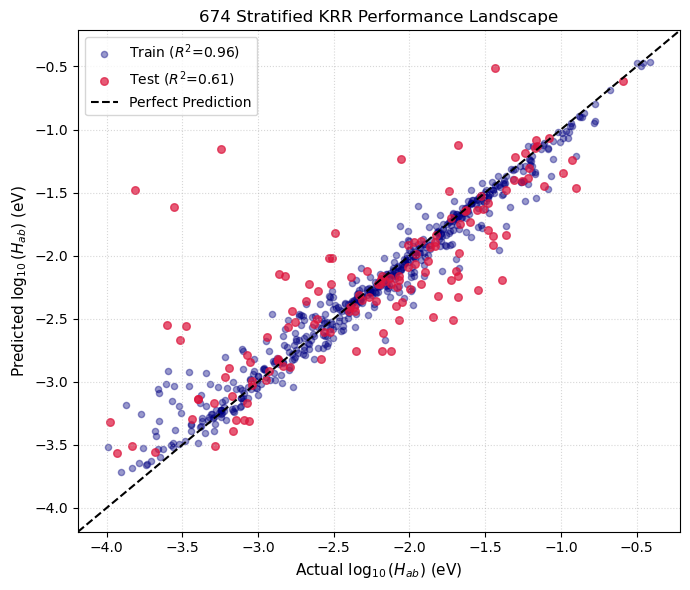

--> Saved evaluation parity plot to: ../SOAP_feature/model/674_heavyatom_soap_feat_model_parity_plot.png


In [44]:
# =====================================================================
# 6. EXPORT PARITY PLOT VISUALIZATION (FULLY SYNCHRONIZED)
# =====================================================================
plt.figure(figsize=(7, 6))

# Plot train and test scatter distributions using the exact dictionary keys
plt.scatter(y_train, y_train_pred, color='navy', alpha=0.4, 
            label=f"Train ($R^2$={metrics['Train']['R2']:.2f})", s=20)

plt.scatter(y_test, y_test_pred, color='crimson', alpha=0.7, 
            label=f"Test ($R^2$={metrics['Test (Hold-Out)']['R2']:.2f})", s=30) # <-- FIXED HERE

# Clean calculation of axis limits based on the actual range of your data
all_actual = np.concatenate([y_train, y_test])
all_pred = np.concatenate([y_train_pred, y_test_pred])

min_val = min(all_actual.min(), all_pred.min()) - 0.2
max_val = max(all_actual.max(), all_pred.max()) + 0.2

# Generate clean diagonal 1:1 line matching graph limits
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, label='Perfect Prediction')

# Plot styling adjustments
plt.title("674 Stratified KRR Performance Landscape", fontsize=12)
plt.xlabel("Actual $\log_{10}(H_{ab})$ (eV)", fontsize=11)
plt.ylabel("Predicted $\log_{10}(H_{ab})$ (eV)", fontsize=11)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

# Save parity plot figure
plot_path = os.path.join(output_dir, "674_heavyatom_soap_feat_model_parity_plot.png")
plt.savefig(plot_path, dpi=300)
plt.show()
print(f"--> Saved evaluation parity plot to: {plot_path}")

Method 2: The Kernel / Similarity Matrix (Best for KRR Validation)

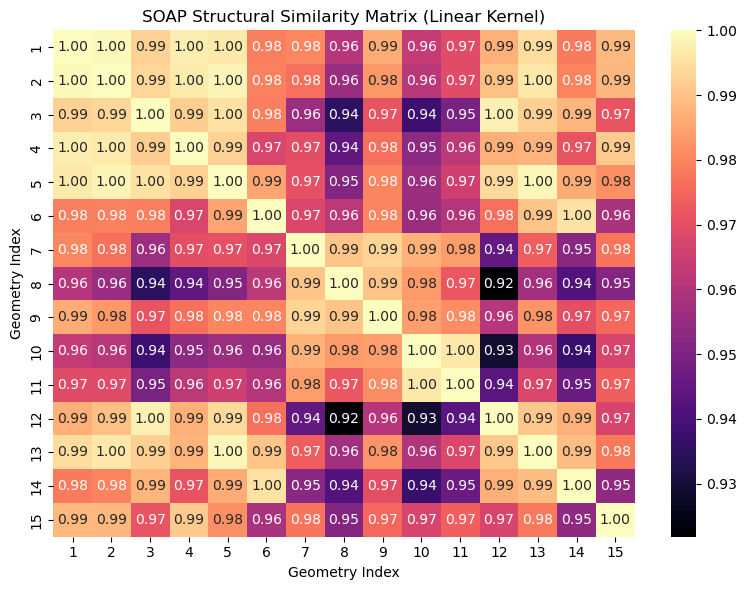

In [13]:
from sklearn.metrics.pairwise import linear_kernel

# Compute the similarity matrix
# Normalizing ensures the diagonal values are exactly 1.0
X_normalized = X_soap / np.linalg.norm(X_soap, axis=1, keepdims=True)
similarity_matrix = linear_kernel(X_normalized)

# Plot the similarity landscape
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="magma", 
            xticklabels=range(1, 16), 
            yticklabels=range(1, 16))

plt.title("SOAP Structural Similarity Matrix (Linear Kernel)")
plt.xlabel("Geometry Index")
plt.ylabel("Geometry Index")
plt.tight_layout()
plt.show()

Distribution plot for similarity matrix

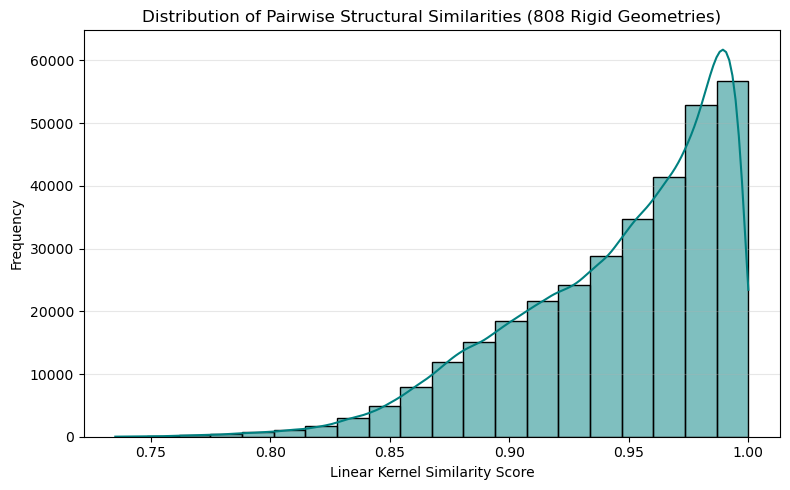

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
X_soap = np.load("../SOAP_feature/808_geometries_rigid_soap_heavyatom_features.npy")
# Extract only the unique upper triangle indices (excluding the diagonal by setting k=1)
# k=1 means we start 1 step above the diagonal, ignoring the 1.0 self-similarity values
# Compute the similarity matrix
# Normalizing ensures the diagonal values are exactly 1.0
X_normalized = X_soap / np.linalg.norm(X_soap, axis=1, keepdims=True)
similarity_matrix = linear_kernel(X_normalized)

row_indices, col_indices = np.triu_indices(808, k=1)
tri_upper = similarity_matrix[row_indices, col_indices]

# Plot the distribution
plt.figure(figsize=(8, 5))
sns.histplot(tri_upper, bins=20, kde=True, color="teal")

plt.title("Distribution of Pairwise Structural Similarities (808 Rigid Geometries)")
plt.xlabel("Linear Kernel Similarity Score")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()